# MDF analysis of ethanol production pathways

Interactive companion to `run_mdf_analysis.py`. Everything here uses the same
`mdf_pathways` module, so the numbers match the committed `results/` exactly.

See `README.md` for the model description and the assumed conditions.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # import mdf_pathways from the repo root

import matplotlib.pyplot as plt
import pandas as pd

import mdf_pathways as mdf

REPO = Path.cwd().parent
MODEL = REPO / "data" / "ethanol_pathway_model.xlsx"
OUT = REPO / "results"

C:\Users\d89659k\AppData\Local\miniconda3\envs\mdf25\Lib\site-packages\equilibrator_cache\models\compound_identifier.py:36: SAWarning: Attribute name 'registry' should be left reserved for the Declarative class registry when using a Declarative class.
  class CompoundIdentifier(TimeStampMixin, Base):
C:\Users\d89659k\AppData\Local\miniconda3\envs\mdf25\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## The pathways defined in the workbook

In [2]:
mdf.list_modes(MODEL)

,name,atp_per_glucose,n_reactions
mode_id,,,
1,Tsac NADH ethanologen,2,15
2,Tsac NADH+NADPH ethanologen,2,16
3,Tsac NADH+NADPH ethanologen fnorp,2,14
4,NFN-only pathway with engineered AdhE,2,14
5,Cth ethanologen WT adhE,3,14
6,Cth malate shunt adhp,3,16
7,PDC ethanol pathway,2,12
8,PDC Xhyd ethanol pathway,2,13
9,Tsac fd adh,2,13


## Conditions applied to every pathway

In [3]:
mdf.read_config()

,Option,Value,Comment
0,algorithm,MDF,MDF (Max-min Driving Force) or ECM
1,p_h,7.0 dimensionless,assumed intracellular pH
2,ionic_strength,0.25 molar,assumed intracellular ionic strength
3,p_mg,3.0 dimensionless,free Mg2+ concentration as -log10(M)
4,temperature,328 kelvin,"55 C, the growth temperature of C. thermocellu..."
5,stdev_factor,1.96,width of the confidence interval on the compon...


## Analyse one pathway

`ComponentContribution` takes a few seconds to build, so make it once and reuse it.

In [4]:
cc = mdf.ComponentContribution()

In [5]:
mode_id = 5  # Cth ethanologen WT adhE

result = mdf.run_mdf(MODEL, mode_id, out_dir=OUT / "sbtab", comp_contrib=cc)

print(f"{result.name}")
print(f"MDF          = {result.mdf_kj_per_mol:.2f} kJ/mol")
print(f"net reaction = {result.net_reaction}")
print(f"bottleneck   = {', '.join(result.bottleneck_reactions)}")
result.ratios()

Cth ethanologen WT adhE
MDF          = 2.16 kJ/mol
net reaction = 3 adp + glc + 3 pi = 3 atp + 2 co2 + 2 etoh + 3 h2o
bottleneck   = fba, tpi, gap, aldh, adh


{'nadh/nad': np.float64(1.5284889157783763),
 'fdred/fdox': np.float64(26.857006347712463),
 'atp/adp': np.float64(1.7869123101722422),
 '[acald] mM': np.float64(3.7752625437212175),
 '[accoa] mM': np.float64(9.999999993462247)}

[WindowsPath('G:/Other computers/Dan Thinkpad P16/Documents (P16 laptop)/Research/Ctherm CBP project/AdhE protein engineering for novel pathway 2025/MDF analysis/mdf-ethanol-pathways/results/figures/M05_Cth_ethanologen_WT_adhE.png'),
 WindowsPath('G:/Other computers/Dan Thinkpad P16/Documents (P16 laptop)/Research/Ctherm CBP project/AdhE protein engineering for novel pathway 2025/MDF analysis/mdf-ethanol-pathways/results/figures/M05_Cth_ethanologen_WT_adhE.pdf')]

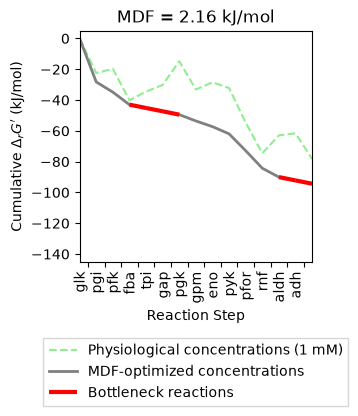

In [6]:
fig = mdf.plot_driving_forces(result)
mdf.save_figure(fig, OUT / "figures" / result.sbtab_path.stem)

Per-reaction driving forces. `optimized_dg_prime` is the ΔrG′ at the MDF optimum;
reactions where it equals −MDF are the bottleneck.

In [7]:
result.reaction_df

,reaction_id,reaction_formula,flux,original_standard_dg_prime,standard_dg_prime,physiological_dg_prime,optimized_dg_prime,shadow_price
0,glk,atp + glc = adp + g6p,1.0 dimensionless,-22.531522177174907 kilojoule / mole,-22.46258803375344 kilojoule / mole,-22.46258803375344 kilojoule / mole,-28.262930693973995 kilojoule / mole,0.00000
1,pgi,g6p = f6p,1.0 dimensionless,2.6625474910579783 kilojoule / mole,2.7347728262884985 kilojoule / mole,2.7347728262884985 kilojoule / mole,-6.59463930763436 kilojoule / mole,0.00000
2,pfk,atp + f6p = adp + fbp,1.0 dimensionless,-20.83358175541133 kilojoule / mole,-20.39161717349235 kilojoule / mole,-20.39161717349235 kilojoule / mole,-8.138333052352072 kilojoule / mole,0.00000
3,fba,fbp = dhap + g3p,1.0 dimensionless,24.042269039866397 kilojoule / mole,22.759681405908587 kilojoule / mole,5.644843871187552 kilojoule / mole,-2.1575994294437013 kilojoule / mole,0.16667
4,tpi,dhap = g3p,1.0 dimensionless,5.615869798610646 kilojoule / mole,4.284929236942384 kilojoule / mole,4.284929236942384 kilojoule / mole,-2.157599429439645 kilojoule / mole,0.16667
5,gap,g3p + nad + pi = bpg + nadh,2.0 dimensionless,-0.9052422461268463 kilojoule / mole,-1.7738730523340673 kilojoule / mole,15.340964482386966 kilojoule / mole,-2.1575994283341204 kilojoule / mole,0.33333
6,pgk,adp + bpg = 3pg + atp,2.0 dimensionless,-19.055097833663694 kilojoule / mole,-18.288928202372997 kilojoule / mole,-18.288928202372997 kilojoule / mole,-4.108111501234502 kilojoule / mole,0.00000
7,gpm,3pg = 2pg,2.0 dimensionless,4.560172068989004 kilojoule / mole,4.653415505273345 kilojoule / mole,4.653415505273345 kilojoule / mole,-3.6882401236525757 kilojoule / mole,0.00000
8,eno,2pg = h2o + pep,2.0 dimensionless,-3.764242131064748 kilojoule / mole,-3.7080932853001998 kilojoule / mole,-3.7080932853001998 kilojoule / mole,-4.691176413802017 kilojoule / mole,0.00000
9,pyk,adp + pep = atp + pyr,2.0 dimensionless,-22.553526805402257 kilojoule / mole,-22.435323195604717 kilojoule / mole,-22.435323195604717 kilojoule / mole,-10.93914892872982 kilojoule / mole,0.00000


Metabolite concentrations chosen by the optimizer, in mM.

In [8]:
result.compound_df[
    ["compound_id", "lower_bound_in_mM", "concentration_in_mM", "upper_bound_in_mM"]
].set_index("compound_id").round(4)

,lower_bound_in_mM,concentration_in_mM,upper_bound_in_mM
compound_id,,,
glc,10.000,10.0000,10.000
atp,0.100,0.1787,10.000
g6p,0.001,1.7194,10.000
adp,0.100,0.1000,0.100
f6p,0.001,0.0398,10.000
fbp,0.001,10.0000,10.000
dhap,0.001,2.4033,10.000
g3p,0.001,0.1785,10.000
pi,10.000,10.0000,10.000


## Compare the two pathways shown in the paper

Mode 5 is the native *C. thermocellum* route with wild-type NADH-linked AdhE; mode 4
replaces RNF with the electron-bifurcating transhydrogenase NfnAB and uses an
NADPH-linked AdhE.

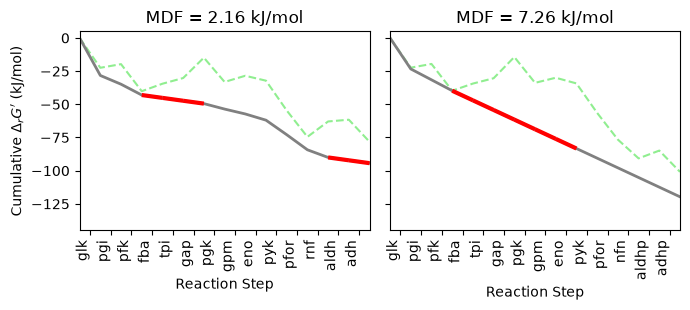

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3.2), sharey=True)

for ax, mode_id in zip(axes, [5, 4]):
    r = mdf.run_mdf(MODEL, mode_id, out_dir=OUT / "sbtab", comp_contrib=cc)
    mdf.plot_driving_forces(r, ax=ax)
    ax.get_legend().remove()

axes[0].set_ylabel(r"Cumulative $\Delta_r G'$ (kJ/mol)")
axes[1].set_ylabel("")
fig.tight_layout()

## All pathways

This is what `python run_mdf_analysis.py` writes to `results/mdf_summary.csv`.

In [10]:
summary = pd.read_csv(OUT / "mdf_summary.csv")
summary[["mode_id", "name", "mdf_kJ_per_mol", "atp_per_glucose", "bottleneck_reactions"]]

,mode_id,name,mdf_kJ_per_mol,atp_per_glucose,bottleneck_reactions
0,4,NFN-only pathway with engineered AdhE,7.26,2,"fba, tpi, gap, pgk, gpm, eno"
1,11,Tsac NADPH substrate-channeling,7.24,2,"fba, tpi, gap, pgk, gpm, eno"
2,9,Tsac fd adh,7.22,2,"fba, tpi, gap, pgk, gpm, eno, aldh"
3,2,Tsac NADH+NADPH ethanologen,4.80,2,"fba, tpi, gap, bif-hyd, nfn, aldh, adhp"
4,3,Tsac NADH+NADPH ethanologen fnorp,4.79,2,"fba, tpi, gap, aldh, adhp"
5,15,Cth malate shunt FNORp adhp,4.08,2,"fba, tpi, gap, pgk, gpm, eno, pepck"
6,7,PDC ethanol pathway,3.25,2,"fba, tpi, gap, adh"
7,6,Cth malate shunt adhp,2.97,3,"fba, tpi, gap, pgk, gpm, eno, pepck, aldh, adhp"
8,10,Tsac NADH substrate-channeling,2.59,2,"fba, tpi, gap, aldh_adh"
9,8,PDC Xhyd ethanol pathway,2.46,2,"fba, tpi, gap, xhyd, adhp"


## Sensitivity: how much does the ethanol titer cost?

Rerunning a pathway across a range of ethanol concentrations shows how the driving force
is consumed as product accumulates. Editing the bound requires rebuilding the SBtab
model, so this writes to a scratch directory.

pathway,M05 Cth WT adhE,M04 NFN + engineered AdhE
etoh_mM,,
10,4.35,7.26
100,3.39,7.26
500,2.73,7.26
1000,2.44,7.26
1500,2.28,7.26
2000,2.16,7.26
2500,2.07,7.26


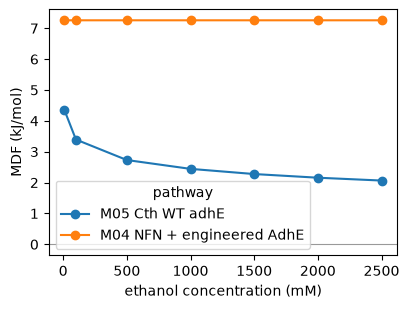

In [11]:
import tempfile

from equilibrator_api import Q_
from equilibrator_pathway import ThermodynamicModel

LABELS = {5: "M05 Cth WT adhE", 4: "M04 NFN + engineered AdhE"}
titers_mM = [10, 100, 500, 1000, 1500, 2000, 2500]
scratch = Path(tempfile.mkdtemp())

rows = []
for mode_id in LABELS:
    _, sbtab_path = mdf.build_sbtab(MODEL, mode_id, out_dir=scratch)
    for titer in titers_mM:
        model = ThermodynamicModel.from_sbtab(str(sbtab_path), comp_contrib=cc)
        model.set_bounds("etoh", Q_(titer, "mM"), Q_(titer, "mM"))
        rows.append({
            "pathway": LABELS[mode_id],
            "etoh_mM": titer,
            "mdf": float(model.mdf_analysis().score),
        })

# pivot sorts its columns, so label the pathways before pivoting rather than after
titration = pd.DataFrame(rows).pivot(index="etoh_mM", columns="pathway", values="mdf")
titration = titration[list(LABELS.values())]

ax = titration.plot(marker="o", figsize=(4.5, 3.2))
ax.set_xlabel("ethanol concentration (mM)")
ax.set_ylabel("MDF (kJ/mol)")
ax.axhline(0, color="0.6", lw=0.8)
titration.round(2)